# K-means on the full EMNIST dataset (PyTorch, CPU/GPU)

Clusters the **entire** EMNIST dataset with **k = 10** using a from-scratch PyTorch K-means.
Reports **training time**, **inference time**, and **carbon footprint** (CodeCarbon).

## Kaggle setup (do this first)
In the right-hand panel under **Settings**:
1. **Accelerator** → `GPU T4 x2` (or `GPU P100`) if you want to run on GPU. Leave as `None` for CPU.
2. **Internet** → **ON** (required so torchvision can download EMNIST and pip can install CodeCarbon).

Then set `DEVICE` in the **Config** cell below (`"cuda"`, `"cpu"`, or `"auto"`) and **Run All**.

## 1. Install dependencies
`torch` / `torchvision` are preinstalled on Kaggle. We only add CodeCarbon.

In [1]:
!pip install -q codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 99.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have c

## 2. Config — edit this cell
This replaces the command-line flags from the script version.

In [2]:
# ------------------------- CONFIG (edit me) ------------------------- #
DEVICE      = "auto"     # "cpu", "cuda", or "auto" (GPU if available)
K           = 10         # number of clusters
SPLIT       = "digits"   # "digits" (280k, 10 classes) | "mnist" | "balanced" | "byclass" ...
MAX_ITER    = 100        # max Lloyd iterations
TOL         = 1e-4       # relative inertia change for convergence
BATCH_SIZE  = 16384      # rows per distance batch (lower if you hit OOM)
SEED        = 42
LIMIT       = None       # None = FULL dataset; set an int for a quick trial
USE_CARBON  = True       # track carbon footprint with CodeCarbon
DATA_ROOT   = "./data"   # where EMNIST is downloaded
# -------------------------------------------------------------------- #

## 3. Imports & device selection

In [3]:
from __future__ import annotations
import time
import numpy as np
import torch


def resolve_device(choice: str) -> torch.device:
    """Turn the DEVICE config into a concrete torch.device."""
    choice = choice.lower()
    if choice == "cpu":
        return torch.device("cpu")
    if choice == "cuda":
        if not torch.cuda.is_available():
            raise RuntimeError("DEVICE='cuda' but no CUDA GPU is available. "
                               "Set Accelerator=GPU in Kaggle Settings, or use 'auto'/'cpu'.")
        return torch.device("cuda")
    if choice == "auto":
        return torch.device("cuda" if torch.cuda.is_available() else "cpu")
    raise ValueError(f"unknown DEVICE '{choice}'. Use cpu, cuda, or auto.")


device = resolve_device(DEVICE)
print(f"Device: {device}"
      + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))

Device: cuda (Tesla T4)


## 4. Load the full EMNIST dataset (train + test)
Needs **Internet = ON**. `digits` gives 240k train + 40k test = **280,000** images across 10 classes.

In [4]:
def load_emnist(split: str, data_root: str, limit):
    """Load the full EMNIST split as flattened float tensors in [0, 1]."""
    from torchvision import datasets, transforms
    tfm = transforms.Compose([transforms.ToTensor()])

    print(f"Loading EMNIST split='{split}' (downloading if needed) ...")
    train = datasets.EMNIST(root=data_root, split=split, train=True,
                            download=True, transform=tfm)
    test  = datasets.EMNIST(root=data_root, split=split, train=False,
                            download=True, transform=tfm)

    def to_tensors(ds):
        X = ds.data.float().div_(255.0).reshape(len(ds), -1).contiguous()
        y = ds.targets.clone().long()
        return X, y

    Xtr, ytr = to_tensors(train)
    Xte, yte = to_tensors(test)
    X = torch.cat([Xtr, Xte], dim=0)
    y = torch.cat([ytr, yte], dim=0)

    if limit is not None and limit < X.shape[0]:
        g = torch.Generator().manual_seed(0)
        idx = torch.randperm(X.shape[0], generator=g)[:limit]
        X, y = X[idx], y[idx]

    print(f"Full dataset loaded: X={tuple(X.shape)}  "
          f"(train={len(train)} + test={len(test)}), "
          f"{y.unique().numel()} true classes")
    return X, y

## 5. K-means core (batched, CPU/GPU agnostic)
k-means++ init, batched nearest-centroid assignment, vectorized centroid updates, empty-cluster reseeding.

In [5]:
@torch.no_grad()
def _pairwise_assign(X, centroids, batch_size):
    """Assign each row of X to nearest centroid (squared Euclidean), in batches."""
    n = X.shape[0]
    labels = torch.empty(n, dtype=torch.long, device=X.device)
    min_sq = torch.empty(n, dtype=X.dtype, device=X.device)
    c_sq = (centroids * centroids).sum(dim=1)  # (k,)
    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        xb = X[start:end]
        # ||x - c||^2 = ||x||^2 - 2 x.c + ||c||^2
        d = (xb @ centroids.t()).mul_(-2.0).add_(c_sq)
        d.add_((xb * xb).sum(dim=1, keepdim=True))
        m, lab = d.min(dim=1)
        labels[start:end] = lab
        min_sq[start:end] = m
    return labels, min_sq


@torch.no_grad()
def kmeans_plusplus_init(X, k, batch_size, generator):
    """k-means++ seeding for stable initial centroids."""
    n, d = X.shape
    centroids = torch.empty(k, d, dtype=X.dtype, device=X.device)
    first = torch.randint(0, n, (1,), generator=generator, device=X.device)
    centroids[0] = X[first]
    _, closest_sq = _pairwise_assign(X, centroids[:1], batch_size)
    for i in range(1, k):
        probs = closest_sq.clamp_min(0)
        total = probs.sum()
        if total <= 0:
            nxt = torch.randint(0, n, (1,), generator=generator, device=X.device)
        else:
            nxt = torch.multinomial(probs / total, 1, generator=generator)
        centroids[i] = X[nxt]
        _, new_sq = _pairwise_assign(X, centroids[i:i + 1], batch_size)
        closest_sq = torch.minimum(closest_sq, new_sq)
    return centroids


@torch.no_grad()
def kmeans_fit(X, k, max_iter, tol, batch_size, seed, verbose=True):
    """Lloyd's algorithm. Returns (centroids, labels, inertia)."""
    dev = X.device
    gen = torch.Generator(device=dev).manual_seed(seed)
    centroids = kmeans_plusplus_init(X, k, batch_size, gen)
    d = X.shape[1]
    prev_inertia = None
    for it in range(max_iter):
        labels, min_sq = _pairwise_assign(X, centroids, batch_size)
        inertia = float(min_sq.sum().item())
        new_centroids = torch.zeros(k, d, dtype=X.dtype, device=dev)
        new_centroids.index_add_(0, labels, X)
        counts = torch.bincount(labels, minlength=k).to(X.dtype).clamp_min(1.0)
        new_centroids /= counts.unsqueeze(1)
        empty = torch.bincount(labels, minlength=k) == 0
        if empty.any():
            worst = torch.topk(min_sq, int(empty.sum().item())).indices
            new_centroids[empty] = X[worst]
        shift = float((new_centroids - centroids).pow(2).sum().sqrt().item())
        centroids = new_centroids
        if verbose:
            print(f"  iter {it + 1:3d}/{max_iter}  inertia={inertia:,.1f}  center_shift={shift:.6f}")
        if prev_inertia is not None and abs(prev_inertia - inertia) <= tol * prev_inertia:
            if verbose:
                print(f"  converged (relative inertia change <= tol={tol})")
            break
        prev_inertia = inertia
    labels, min_sq = _pairwise_assign(X, centroids, batch_size)
    inertia = float(min_sq.sum().item())
    return centroids, labels, inertia

## 6. Evaluation vs. ground-truth labels
Clustering accuracy (Hungarian matching), plus NMI and ARI.

In [6]:
def evaluate(labels, y_true, k):
    lab = labels.cpu().numpy()
    yt = y_true.cpu().numpy()
    n_classes = int(yt.max()) + 1
    cost = np.zeros((k, n_classes), dtype=np.int64)
    for c, t in zip(lab, yt):
        cost[c, t] += 1
    acc = None
    try:
        from scipy.optimize import linear_sum_assignment
        row, col = linear_sum_assignment(-cost)
        acc = cost[row, col].sum() / len(yt)
    except Exception as e:
        print(f"  (accuracy skipped: {e})")
    nmi = ari = None
    try:
        from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
        nmi = normalized_mutual_info_score(yt, lab)
        ari = adjusted_rand_score(yt, lab)
    except Exception:
        pass
    return acc, nmi, ari

## 7. Run: load → fit → infer, with timing + carbon tracking

In [7]:
# Carbon tracker (graceful if unavailable in the Kaggle container)
tracker = None
if USE_CARBON:
    try:
        from codecarbon import EmissionsTracker
        tracker = EmissionsTracker(project_name="kmeans_emnist",
                                   measure_power_secs=5, save_to_file=True,
                                   output_dir=".", log_level="error")
    except Exception as e:
        print(f"CodeCarbon unavailable ({e}); continuing without it.")

# Data
X_cpu, y_true = load_emnist(SPLIT, DATA_ROOT, LIMIT)

# ---- Training (fit) ----
if tracker:
    tracker.start()
X = X_cpu.to(device, non_blocking=True)
if device.type == "cuda":
    torch.cuda.synchronize()
t0 = time.perf_counter()
centroids, labels, inertia = kmeans_fit(X, K, MAX_ITER, TOL, BATCH_SIZE, SEED, verbose=True)
if device.type == "cuda":
    torch.cuda.synchronize()
train_time = time.perf_counter() - t0

# ---- Inference (assign all points to final centroids) ----
t1 = time.perf_counter()
labels, _ = _pairwise_assign(X, centroids, BATCH_SIZE)
if device.type == "cuda":
    torch.cuda.synchronize()
infer_time = time.perf_counter() - t1

emissions = tracker.stop() if tracker else None

[codecarbon WARNING @ 12:39:13] Multiple instances of codecarbon are allowed to run at the same time.


Loading EMNIST split='digits' (downloading if needed) ...


100%|██████████| 562M/562M [00:02<00:00, 233MB/s]


Full dataset loaded: X=(280000, 784)  (train=240000 + test=40000), 10 true classes
  iter   1/100  inertia=21,957,086.0  center_shift=16.826527
  iter   2/100  inertia=13,873,094.0  center_shift=3.550077
  iter   3/100  inertia=13,328,012.0  center_shift=2.012817
  iter   4/100  inertia=13,140,860.0  center_shift=1.359945
  iter   5/100  inertia=13,053,526.0  center_shift=0.941985
  iter   6/100  inertia=13,010,962.0  center_shift=0.670633
  iter   7/100  inertia=12,987,946.0  center_shift=0.548767
  iter   8/100  inertia=12,971,648.0  center_shift=0.485509
  iter   9/100  inertia=12,958,510.0  center_shift=0.440865
  iter  10/100  inertia=12,948,012.0  center_shift=0.378447
  iter  11/100  inertia=12,940,435.0  center_shift=0.324076
  iter  12/100  inertia=12,935,070.0  center_shift=0.276922
  iter  13/100  inertia=12,931,112.0  center_shift=0.241036
  iter  14/100  inertia=12,928,010.0  center_shift=0.231693
  iter  15/100  inertia=12,925,216.0  center_shift=0.210047
  iter  16/100  

## 8. Results

In [8]:
acc, nmi, ari = evaluate(labels, y_true, K)

print("=" * 60)
print("RESULTS")
print("=" * 60)
print(f"Samples clustered      : {X.shape[0]:,}")
print(f"Feature dim            : {X.shape[1]}")
print(f"k                      : {K}")
print(f"Device                 : {device}")
print(f"Final inertia (SSE)    : {inertia:,.1f}")
print(f"Training time          : {train_time:.3f} s")
print(f"Inference time (assign): {infer_time:.3f} s")
thr = X.shape[0] / infer_time if infer_time > 0 else float('nan')
print(f"Inference throughput   : {thr:,.0f} samples/s")
if acc is not None:
    print(f"Clustering accuracy    : {acc:.4f}  (Hungarian-matched)")
if nmi is not None:
    print(f"NMI                    : {nmi:.4f}")
if ari is not None:
    print(f"ARI                    : {ari:.4f}")
if emissions is not None:
    print(f"Carbon footprint       : {emissions*1000:.3f} g CO2eq "
          f"({emissions:.6e} kg)  [see emissions.csv]")
print("=" * 60)

RESULTS
Samples clustered      : 280,000
Feature dim            : 784
k                      : 10
Device                 : cuda
Final inertia (SSE)    : 12,911,967.0
Training time          : 1.527 s
Inference time (assign): 0.019 s
Inference throughput   : 14,363,819 samples/s
Clustering accuracy    : 0.5784  (Hungarian-matched)
NMI                    : 0.4912
ARI                    : 0.3805
Carbon footprint       : 0.018 g CO2eq (1.822655e-05 kg)  [see emissions.csv]


## 9. Visualize the 10 cluster centroids
Each centroid is the mean image of its cluster, reshaped to 28×28.

> Note: EMNIST images are stored transposed relative to how we usually view them, so we `.T` each centroid for display.

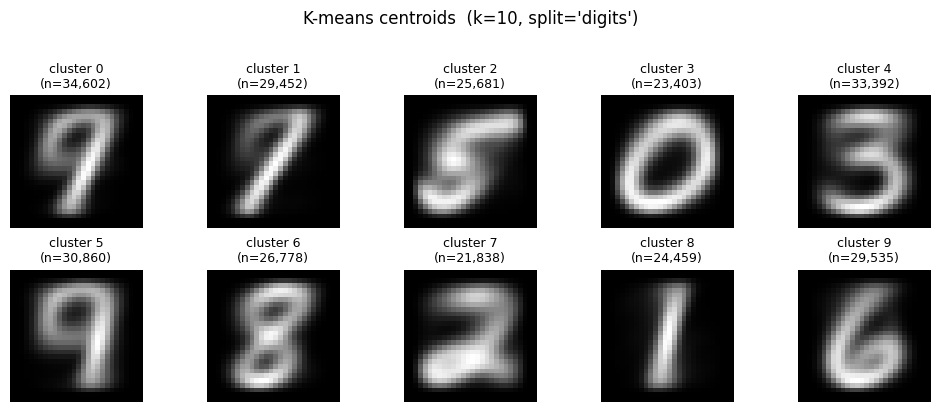

In [9]:
import matplotlib.pyplot as plt

cents = centroids.detach().cpu().numpy().reshape(K, 28, 28)
counts = torch.bincount(labels, minlength=K).cpu().numpy()

cols = 5
rows = (K + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows))
for i, ax in enumerate(axes.ravel()):
    if i < K:
        ax.imshow(cents[i].T, cmap="gray")   # .T to correct EMNIST orientation
        ax.set_title(f"cluster {i}\n(n={counts[i]:,})", fontsize=9)
    ax.axis("off")
plt.suptitle(f"K-means centroids  (k={K}, split='{SPLIT}')", y=1.02)
plt.tight_layout()
plt.show()